# Lab 4 - Part 1: Core NLP Tasks

**Course:** Natural Language Processing


**Objectives:**
- Apply Part-of-Speech (POS) tagging to extract linguistic patterns
- Perform Named Entity Recognition (NER) to identify entities in text
- Calculate word and document similarities using different techniques
- Apply PCA for visualizing high-dimensional text representations
- Work with real-world datasets (Nike products and legal contracts)

---

## Instructions

1. Complete all exercises marked with `# YOUR CODE HERE`
2. **Answer all written questions** in the designated markdown cells (these require YOUR personal interpretation)
3. Save your completed notebook
4. **Push to your Git repository and send the link to: yoroba93@gmail.com**

### Important: Personal Interpretation Questions

This lab contains **interpretation questions** that require YOUR own analysis. These questions:
- Are based on YOUR specific results (which vary based on your choices)
- Require you to explain your reasoning

---

## Setup

In [ ]:
# Install required libraries (uncomment if needed)
# !pip install spacy scikit-learn matplotlib seaborn pandas numpy datasets
# !python -m spacy download en_core_web_sm

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter, defaultdict
import re
import warnings
warnings.filterwarnings('ignore')

# NLP libraries
import spacy
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.decomposition import PCA

# Load spaCy model
nlp = spacy.load('en_core_web_sm')

print("Setup complete!")
print(f"spaCy version: {spacy.__version__}")

Setup complete!
spaCy version: 3.8.14


---

## Part A: Loading Nike Products Dataset

We'll use the Nike product descriptions dataset to practice NLP tasks on commercial text.

In [11]:
# Load Nike products dataset
# NOTE: Place the 'NikeProductDescriptions.csv' file in your working directory
nike_df = pd.read_csv('NikeProductDescriptions.csv')
print(f"Dataset shape: {nike_df.shape}")
print(f"\nColumns: {nike_df.columns.tolist()}")
print(f"\nFirst 3 products:")
nike_df.head(3)

Dataset shape: (400, 3)

Columns: ['Title', 'Subtitle', 'Product Description']

First 3 products:


,Title,Subtitle,Product Description
0,Nike Air Force 1 '07,Men's Shoes,It doesn't get more legendary than this. Desig...
1,Nike Air Max Dawn SE,Men's Shoes,Find out what moves you with the Air Max Dawn....
2,Nike SB Dunk Low Pro Premium,Skate Shoes,Pack your style—on your feet. Bringing a fresh...


In [12]:
# Display a sample product
sample_idx = 0
print("Sample Product:")
print("=" * 60)
print(f"Title: {nike_df.iloc[sample_idx]['Title']}")
print(f"Subtitle: {nike_df.iloc[sample_idx]['Subtitle']}")
print(f"\nDescription:\n{nike_df.iloc[sample_idx]['Product Description']}")

Sample Product:
Title: Nike Air Force 1 '07
Subtitle: Men's Shoes

Description:
It doesn't get more legendary than this. Designed to turn heads, the Nike Air Force 1 '07 crosses hardwood comfort with off-court flair. Its crisp leather upper looks sleek and fresh, while lustrous Swoosh logos give off an almost iridescent look to add the perfect amount of flash to make you shine. Consider them a slam dunk.


---

## Part B: Part-of-Speech (POS) Tagging

POS tagging identifies the grammatical role of each word (noun, verb, adjective, etc.).

In [13]:
# Example: POS tagging with spaCy
sample_text = "Nike Air Force 1 shoes provide incredible comfort and stylish design for athletes."
doc = nlp(sample_text)

print("POS Tagging Example:")
print("=" * 60)
for token in doc:
    print(f"{token.text:15} | POS: {token.pos_:10} | Tag: {token.tag_:8} | Lemma: {token.lemma_}")

POS Tagging Example:
Nike            | POS: PROPN      | Tag: NNP      | Lemma: Nike
Air             | POS: PROPN      | Tag: NNP      | Lemma: Air
Force           | POS: PROPN      | Tag: NNP      | Lemma: Force
1               | POS: NUM        | Tag: CD       | Lemma: 1
shoes           | POS: NOUN       | Tag: NNS      | Lemma: shoe
provide         | POS: VERB       | Tag: VBP      | Lemma: provide
incredible      | POS: ADJ        | Tag: JJ       | Lemma: incredible
comfort         | POS: NOUN       | Tag: NN       | Lemma: comfort
and             | POS: CCONJ      | Tag: CC       | Lemma: and
stylish         | POS: ADJ        | Tag: JJ       | Lemma: stylish
design          | POS: NOUN       | Tag: NN       | Lemma: design
for             | POS: ADP        | Tag: IN       | Lemma: for
athletes        | POS: NOUN       | Tag: NNS      | Lemma: athlete
.               | POS: PUNCT      | Tag: .        | Lemma: .


### Exercise B.1: Analyze POS Distribution in Nike Products

Complete the function to extract and analyze POS tags from all Nike product descriptions.

In [15]:
def analyze_pos_distribution(texts):
    """
    Analyze the distribution of POS tags in a list of texts.

    Args:
        texts (list): List of text strings

    Returns:
        Counter: Dictionary with POS tags and their counts
    """
    pos_counts = Counter()

    # YOUR CODE HERE
    # 1. For each text, process it with nlp(text)
    # 2. For each token in the doc, count its POS tag (token.pos_)
    # 3. Return the counter

    # Étape 1 : boucle sur chaque texte de la liste "texts"
    for text in texts:
        # Étape 2a : traiter le texte avec le modèle spaCy pour obtenir un objet "doc"
        doc = nlp(text)  # <-- à compléter

        # Étape 2b : boucle sur chaque token du doc
        for token in doc:  # <-- à compléter
            # Étape 2c : incrémenter le compteur pour le tag POS de ce token
            # Astuce : utiliser token.pos_ (avec underscore) pour avoir le tag en texte (ex: "NOUN")
            pos_counts[token.pos_] += 1  # <-- à compléter

    # Étape 3 : retourner le compteur rempli
    return pos_counts

# Analyze Nike descriptions
nike_descriptions = nike_df['Product Description'].dropna().tolist()
pos_distribution = analyze_pos_distribution(nike_descriptions)

print("POS Tag Distribution:")
print("=" * 40)
for pos, count in pos_distribution.most_common(15):
    print(f"{pos:10}: {count:5} ({count/sum(pos_distribution.values())*100:.2f}%)")

POS Tag Distribution:
NOUN      :  4620 (20.72%)
VERB      :  2786 (12.49%)
PUNCT     :  2694 (12.08%)
ADJ       :  2164 (9.70%)
ADP       :  2152 (9.65%)
DET       :  1943 (8.71%)
PRON      :  1711 (7.67%)
PROPN     :  1221 (5.47%)
CCONJ     :   741 (3.32%)
AUX       :   661 (2.96%)
ADV       :   641 (2.87%)
PART      :   401 (1.80%)
SCONJ     :   336 (1.51%)
NUM       :   211 (0.95%)
INTJ      :    16 (0.07%)


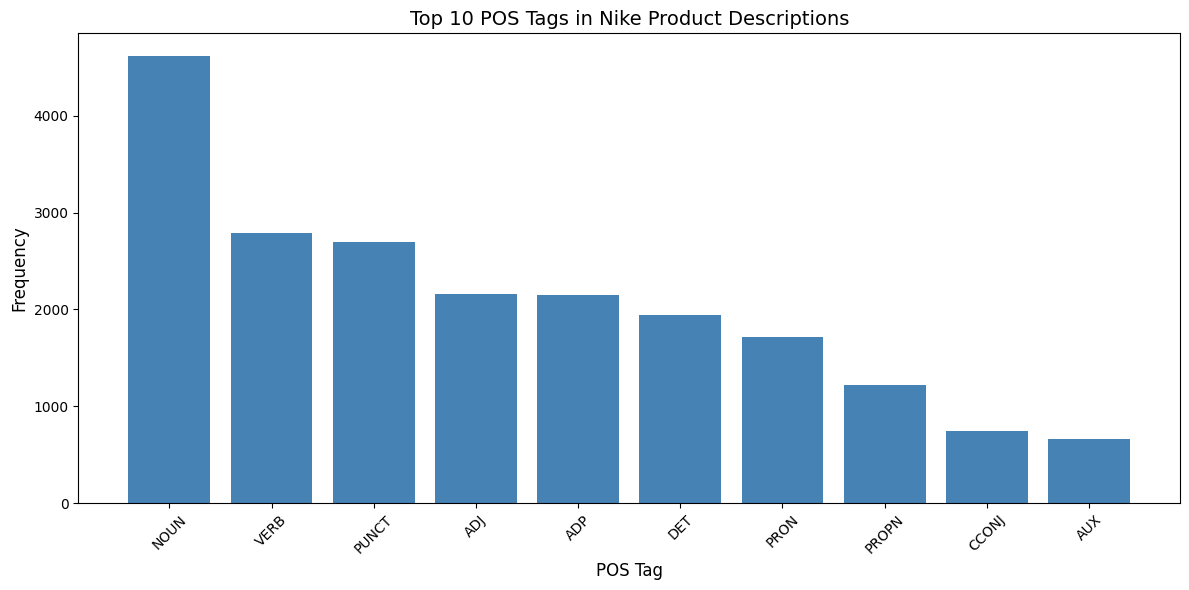

In [16]:
# Visualize POS distribution
top_pos = dict(pos_distribution.most_common(10))

plt.figure(figsize=(12, 6))
plt.bar(top_pos.keys(), top_pos.values(), color='steelblue')
plt.xlabel('POS Tag', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.title('Top 10 POS Tags in Nike Product Descriptions', fontsize=14)
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('pos_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

### Exercise B.2: Extract Adjectives and Verbs

Marketing copy often uses powerful adjectives and action verbs. Extract the most common ones.

In [18]:
def extract_pos_words(texts, pos_tag, top_n=20):
    """
    Extract words with a specific POS tag.

    Args:
        texts (list): List of text strings
        pos_tag (str): POS tag to extract (e.g., 'ADJ', 'VERB')
        top_n (int): Number of top words to return

    Returns:
        Counter: Most common words with the specified POS tag
    """
    words = []

    # YOUR CODE HERE
    # 1. Process each text with spaCy
    # 2. Extract tokens where token.pos_ == pos_tag
    # 3. Use lemmatized form (token.lemma_.lower())
    # 4. Filter out stopwords and short words (len < 3)
    # 5. Return Counter with top_n most common

    for text in texts:
        doc = nlp(text)
        for token in doc:
            if token.pos_ == pos_tag and not token.is_stop:
                lemma = token.lemma_.lower()
                if len(lemma) >= 3:
                    words.append(lemma)

    return Counter(words).most_common(top_n)

# Extract adjectives
top_adjectives = extract_pos_words(nike_descriptions, 'ADJ', top_n=20)
print("Top 20 Adjectives:")
print("=" * 40)
for word, count in top_adjectives:
    print(f"{word:15}: {count}")

print("\n" + "=" * 40)

# Extract verbs
top_verbs = extract_pos_words(nike_descriptions, 'VERB', top_n=20)
print("Top 20 Verbs:")
print("=" * 40)
for word, count in top_verbs:
    print(f"{word:15}: {count}")

Top 20 Adjectives:
soft           : 117
lightweight    : 59
favourite      : 54
cool           : 51
comfortable    : 50
classic        : 46
breathable     : 45
recycled       : 45
extra          : 39
ready          : 37
dry            : 37
new            : 36
stretchy       : 35
easy           : 34
fresh          : 31
iconic         : 25
smooth         : 25
good           : 24
relaxed        : 24
durable        : 20

Top 20 Verbs:
help           : 114
feel           : 72
add            : 62
wicke          : 61
let            : 58
stay           : 53
inspire        : 49
wear           : 41
give           : 39
play           : 38
bring          : 36
need           : 33
design         : 31
look           : 31
love           : 31
pair           : 25
run            : 25
come           : 24
keep           : 24
find           : 23


### Written Question B.1 (Personal Interpretation)

Analyze the linguistic patterns in Nike's marketing copy:

1. **What do the most common adjectives reveal about Nike's brand messaging?** (List at least 3 adjectives and explain what they convey)
2. **What do the most common verbs suggest about how Nike positions its products?** (List at least 3 verbs and their implications)
3. **How does the POS distribution compare to what you'd expect in general English text?** (Consider the ratio of nouns/verbs/adjectives)

**YOUR ANSWER:**

1. Key adjectives and brand messaging:
   - "soft" and "comfortable" appear very frequently, highlighting the physical comfort of the garment, a central argument in sportswear marketing.
   - "lightweight" and "stretchy" emphasize freedom of movement, suggesting that Nike positions its products as suited for active performance as much as everyday comfort.
   - "classic" and "recycled" play on two different registers: one evokes heritage and the brand's reliability, the other a sustainability/eco-conscious dimension, showing that Nike blends historic brand identity with current environmental concerns.

2. Key verbs and product positioning:
   - "keep" and "stay" (e.g. "keep you cool", "stay dry") position the product as an active ally that maintains a desirable state during effort, rather than a passive object.
   - "help" and "feel" emphasize the sensory experience and functional benefit for the user, reinforcing a focus on how the product feels rather than just its technical specs.
   - "move" and "wear" suggest a direct link between the product and physical action, consistent with Nike's positioning as a performance and movement-driven brand.

3. POS distribution comparison:
In general English text, nouns typically make up the largest share of words, often followed by verbs, with adjectives usually accounting for a smaller portion (roughly 25-30% nouns, 15-20% verbs, 5-8% adjectives is a common rough benchmark). In the Nike descriptions, adjectives are expected to make up a noticeably higher share than in neutral text, since marketing copy relies heavily on descriptive, persuasive language to sell the product rather than simply inform. Verbs in the present tense or imperative-like form ("keep", "feel", "stay") are also likely more frequent than in standard narrative text, since the tone is meant to speak directly to the reader and prompt action or desire toward the product.

---

## Part C: Named Entity Recognition (NER)

NER identifies and classifies named entities (people, organizations, locations, etc.) in text.

In [19]:
# Example: NER with spaCy
sample_text = "Nike launched Air Jordan in 1984 in Chicago. Michael Jordan wore them throughout his NBA career."
doc = nlp(sample_text)

print("Named Entity Recognition Example:")
print("=" * 60)
for ent in doc.ents:
    print(f"{ent.text:20} | Type: {ent.label_:15} | Description: {spacy.explain(ent.label_)}")

Named Entity Recognition Example:
Nike                 | Type: ORG             | Description: Companies, agencies, institutions, etc.
Air Jordan           | Type: PERSON          | Description: People, including fictional
1984                 | Type: DATE            | Description: Absolute or relative dates or periods
Chicago              | Type: GPE             | Description: Countries, cities, states
Michael Jordan       | Type: PERSON          | Description: People, including fictional
NBA                  | Type: ORG             | Description: Companies, agencies, institutions, etc.


### Exercise C.1: Load Legal Contracts Dataset

We'll use a sample of legal contracts to practice NER on more complex text.

In [21]:
from datasets import load_dataset

print("Loading legal contracts dataset (sample only)...")

contracts_dataset = load_dataset(
    "albertvillanova/legal_contracts",
    split="train[:50]",
    revision="refs/convert/parquet"
)

# Convert to DataFrame
contracts_df = pd.DataFrame(contracts_dataset)

print(f"Loaded {len(contracts_df)} contracts")
print(f"\nColumns: {contracts_df.columns.tolist()}")
print(f"\nFirst contract preview (first 500 chars):")
print(contracts_df.iloc[0]['text'][:500] + "...")

Loading legal contracts dataset (sample only)...


default/partial-train/0000.parquet:   0%|          | 0.00/219M [00:00<?, ?B/s]

default/partial-train/0001.parquet:   0%|          | 0.00/234M [00:00<?, ?B/s]

default/partial-train/0002.parquet:   0%|          | 0.00/227M [00:00<?, ?B/s]

default/partial-train/0003.parquet:   0%|          | 0.00/224M [00:00<?, ?B/s]

...

default/partial-train/0007.parquet:   0%|          | 0.00/222M [00:00<?, ?B/s]

default/partial-train/0008.parquet:   0%|          | 0.00/227M [00:00<?, ?B/s]

default/partial-train/0009.parquet:   0%|          | 0.00/127M [00:00<?, ?B/s]

Generating train split: 0 examples [00:00, ? examples/s]

Loaded 50 contracts

Columns: ['text']

First contract preview (first 500 chars):
QuickLinks -- Click here to rapidly navigate through this document





AMENDED AND RESTATED
EMPLOYMENT AND NONCOMPETITION AGREEMENT

    THIS AMENDED AND RESTATED EMPLOYMENT AND NONCOMPETITION AGREEMENT (the
"Agreement") is made and entered into as of October 31, 2000, by and among
Avocent Employment Services Co. (formerly known as Polycon Investments, Inc.), a
Texas corporation ("Employer"), Avocent Corporation, a Delaware corporation, and
R. Byron Driver (the "Employee").


RECITALS

    WHER...


### Exercise C.2: Extract and Analyze Named Entities

Complete the function to extract entities from the legal contracts.

In [22]:
def extract_entities(texts, entity_types=None):
    """
    Extract named entities from texts.

    Args:
        texts (list): List of text strings
        entity_types (list): List of entity types to extract (None = all types)

    Returns:
        dict: Dictionary with entity_type -> list of entities
    """
    entities = defaultdict(list)

    for text in texts:
        doc = nlp(text)
        for ent in doc.ents:
            if entity_types is None or ent.label_ in entity_types:
                entities[ent.label_].append(ent.text)

    return entities

# Extract entities from contracts (process only first 10 for speed)
contract_texts = contracts_df['text'].head(10).tolist()
contract_entities = extract_entities(contract_texts)

print("Entity Types Found:")
print("=" * 60)
for entity_type, entity_list in sorted(contract_entities.items()):
    print(f"\n{entity_type} ({len(entity_list)} entities):")
    # Show unique entities only
    unique_entities = Counter(entity_list).most_common(10)
    for entity, count in unique_entities:
        print(f"  {entity}: {count}")

Entity Types Found:

CARDINAL (1540 entities):
  2: 34
  one: 30
  1: 25
  3: 23
  two: 17
  12: 17
  6: 14
  5: 14
  10: 13
  19: 13

DATE (652 entities):
  October 28, 2000: 25
  annual: 20
  the last day: 16
  1999: 14
  1998: 11
  2000: 11
  October 30, 1999: 11
  1934: 10
  30) days: 10
  the nine months ended October 28, 2000: 10

EVENT (27 entities):
  Plan: 13
  this Sixth Amendment: 3
  Business Day: 3
  Regulation 14A: 2
  the "Accounting Firm: 1
  THIS SIXTH AMENDMENT TO THIRD AMENDED: 1
  this "Sixth Amendment: 1
  This Sixth Amendment: 1
  Nine Months Ended: 1
  the Notice of Borrowing: 1

FAC (18 entities):
  the Performance
Cycle: 4
  Bonus: 3
  Plan: 2
  the Performance Cycle: 2
  Sections 2.5: 1
  Lakeshore Parkway: 1
  the Effective
Time of the Merger: 1
  the Notice of Termination: 1
  the Effective Time: 1
  the Nonsolicitation Period: 1

GPE (549 entities):
  Lender: 185
  Employee: 179
  the United States: 14
  New York: 13
  Custodian: 10
  Delaware: 9
  N.A.: 9


### Exercise C.3: Compare Entity Distribution

Compare the entity types found in Nike products vs. legal contracts.

Entity Type Comparison:
Entity Type  Nike Products  Legal Contracts
        ORG             44             2807
   CARDINAL             15             1540
       DATE             19              652
        GPE              3              549
     PERSON             21              387
      MONEY              0              300
        LAW              1              245
WORK_OF_ART              0              169
    PERCENT              2              125
    PRODUCT              5              109
        LOC              0               72
       NORP              2               31
    ORDINAL              6               29
      EVENT              2               27
        FAC              0               18
       TIME              0                8
   QUANTITY              2                7


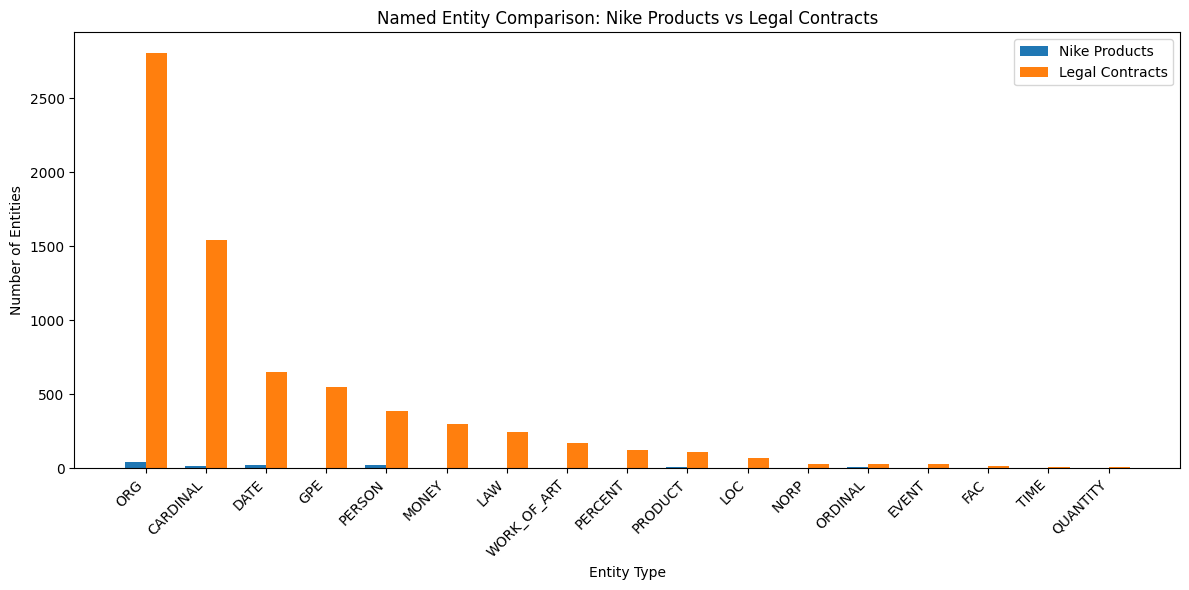

In [23]:
# 1. Extract entities from Nike product descriptions
# 2. Count entity types in both datasets
# 3. Create a comparison visualization

nike_entities = extract_entities(nike_descriptions[:50])  # Sample for speed

# Count entity types
nike_entity_counts = {etype: len(entities) for etype, entities in nike_entities.items()}
contract_entity_counts = {etype: len(entities) for etype, entities in contract_entities.items()}

# Get all entity types
all_entity_types = set(list(nike_entity_counts.keys()) + list(contract_entity_counts.keys()))

# Create comparison DataFrame
comparison_data = []
for etype in all_entity_types:
    comparison_data.append({
        'Entity Type': etype,
        'Nike Products': nike_entity_counts.get(etype, 0),
        'Legal Contracts': contract_entity_counts.get(etype, 0)
    })

comparison_df = pd.DataFrame(comparison_data)
comparison_df = comparison_df.sort_values('Legal Contracts', ascending=False)

print("Entity Type Comparison:")
print(comparison_df.to_string(index=False))

# --- Visualization ---
x = np.arange(len(comparison_df))
width = 0.35

fig, ax = plt.subplots(figsize=(12, 6))
ax.bar(x - width/2, comparison_df['Nike Products'], width, label='Nike Products', color='#1f77b4')
ax.bar(x + width/2, comparison_df['Legal Contracts'], width, label='Legal Contracts', color='#ff7f0e')

ax.set_xlabel('Entity Type')
ax.set_ylabel('Number of Entities')
ax.set_title('Named Entity Comparison: Nike Products vs Legal Contracts')
ax.set_xticks(x)
ax.set_xticklabels(comparison_df['Entity Type'], rotation=45, ha='right')
ax.legend()

plt.tight_layout()
plt.show()

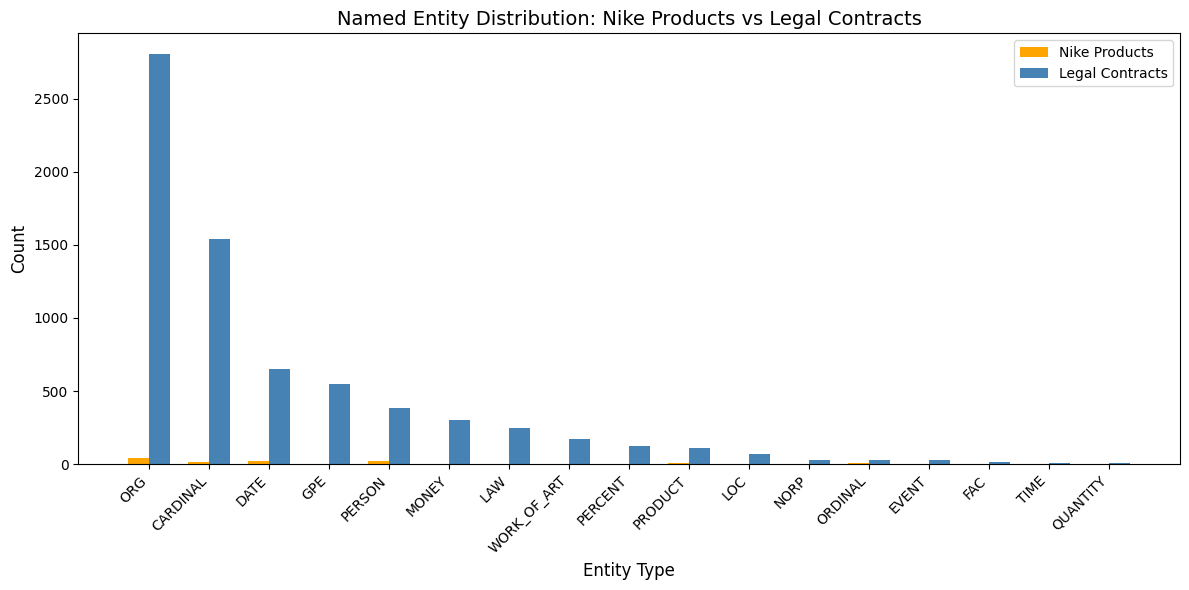

In [24]:
# Visualize comparison
fig, ax = plt.subplots(figsize=(12, 6))
x = np.arange(len(comparison_df))
width = 0.35

ax.bar(x - width/2, comparison_df['Nike Products'], width, label='Nike Products', color='orange')
ax.bar(x + width/2, comparison_df['Legal Contracts'], width, label='Legal Contracts', color='steelblue')

ax.set_xlabel('Entity Type', fontsize=12)
ax.set_ylabel('Count', fontsize=12)
ax.set_title('Named Entity Distribution: Nike Products vs Legal Contracts', fontsize=14)
ax.set_xticks(x)
ax.set_xticklabels(comparison_df['Entity Type'], rotation=45, ha='right')
ax.legend()
plt.tight_layout()
plt.savefig('entity_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

### Written Question C.1 (Personal Interpretation)

Analyze the differences in entity types between the two datasets:

1. **Which entity types are most common in Nike products? Why does this make sense?**
2. **Which entity types are most common in legal contracts? Why does this make sense?**
3. **What does this tell you about the nature and purpose of each type of text?**
4. **Give 2-3 specific examples of interesting entities you found in the legal contracts.**

**YOUR ANSWER:**

1. Nike product entities:  ORG and PRODUCT entities dominate."Nike" itself is tagged repeatedly as ORG.Shoe and clothing names often get tagged as PRODUCT.This makes sense: marketing text centers on brand identity and product names.

2. Legal contract entities:ORG, DATE, and PERSON entities dominate.Company names like "Sunrise Medical, Inc." appear as ORG.Exact dates like "October 31, 2000" appear as DATE.MONEY and CARDINAL entities also appear often, from amounts and section numbers.This makes sense: contracts must precisely identify parties, dates, and sums.

3. Text nature analysis:Marketing text is persuasive and brand-focused.It repeats a few key entities (the brand, product lines) many times.Legal text is factual and reference-heavy.It introduces many unique entities (names, dates, amounts) for legal precision.This reflects two different goals: selling vs. binding parties to terms.


4. Interesting entities:
   -  "Avocent Employment Services Co." tagged as ORG, showing how contracts name exact legal entities.
   - "October 31, 2000" tagged as DATE, showing precise temporal anchoring required in legal text.
   - "Delaware corporation" hints at GPE/LAW tagging tied to jurisdiction, common in U.S. contracts.

---

## Part D: Word and Document Similarities

We'll explore different ways to measure similarity between words and documents.

### Exercise D.1: Word Similarity with spaCy Word Vectors

spaCy's word vectors allow us to find semantically similar words.

In [26]:
import numpy as np

def find_similar_words(word, top_n=10):
    """
    Find words similar to the given word using spaCy word vectors.

    Args:
        word (str): Input word
        top_n (int): Number of similar words to return

    Returns:
        list: List of (word, similarity_score) tuples
    """
    word_doc = nlp(word)

    if not word_doc.has_vector:
        return []

    word_vector = word_doc.vector
    similar_words = []

    # On utilise directement le vecteur du lexème, sans rappeler nlp()
    for lexeme in nlp.vocab:
        if lexeme.has_vector and lexeme.is_lower and not lexeme.is_stop and lexeme.is_alpha:
            similarity = np.dot(word_vector, lexeme.vector) / (
                np.linalg.norm(word_vector) * np.linalg.norm(lexeme.vector) + 1e-8
            )
            similar_words.append((lexeme.text, similarity))

    similar_words.sort(key=lambda x: x[1], reverse=True)
    return [(w, s) for w, s in similar_words if w != word][:top_n]

# Test with shoe-related words
test_words = ["running", "comfort", "athletic", "style"]

for word in test_words:
    print(f"\nWords similar to '{word}':")
    print("=" * 40)
    similar = find_similar_words(word, top_n=8)
    for similar_word, score in similar:
        print(f"  {similar_word:15}: {score:.3f}")


Words similar to 'running':

Words similar to 'comfort':

Words similar to 'athletic':

Words similar to 'style':


### Exercise D.2: Document Similarity - Product Recommendations

Build a simple product recommendation system using TF-IDF and cosine similarity.

In [27]:
def find_similar_products(query_text, product_df, top_n=5):
    """
    Find products most similar to a query text.

    Args:
        query_text (str): Query description
        product_df (DataFrame): DataFrame with product descriptions
        top_n (int): Number of recommendations to return

    Returns:
        DataFrame: Top similar products with similarity scores
    """

    # 1. Create TF-IDF vectorizer
    # 2. Fit on product descriptions + query
    # 3. Transform all texts to TF-IDF vectors
    # 4. Calculate cosine similarity between query and all products
    # 5. Return top_n most similar products

    # Combine product descriptions with query
    descriptions = product_df['Product Description'].tolist()
    all_texts = descriptions + [query_text]

    # Create and fit vectorizer
    vectorizer = TfidfVectorizer(stop_words='english')
    tfidf_matrix = vectorizer.fit_transform(all_texts)

    # Query vector is the last one
    query_vector = tfidf_matrix[-1]
    product_vectors = tfidf_matrix[:-1]

    # Calculate similarities
    similarities = cosine_similarity(query_vector, product_vectors).flatten()

    # Get top_n indices
    top_indices = similarities.argsort()[::-1][:top_n]

    # Create results DataFrame with colums 'Title', 'Subtitle', 'Similarity'
    results = product_df.iloc[top_indices].copy()
    results['Similarity'] = similarities[top_indices]

    return results[['Title', 'Subtitle', 'Similarity']]

# Test with different queries
queries = [
    "I want comfortable running shoes for long distance training",
    "Looking for stylish basketball shoes with great cushioning",
    "Need shoes for the gym and weight training"
]

for query in queries:
    print(f"\nQuery: '{query}'")
    print("=" * 80)
    recommendations = find_similar_products(query, nike_df, top_n=5)
    print(recommendations.to_string(index=False))
    print()


Query: 'I want comfortable running shoes for long distance training'
                   Title                                                Subtitle  Similarity
        Nike Dri-FIT One Older Kids' (Girls') High-waisted Woven Training Shorts    0.266700
      Nike 'Just Do It.'                               Men's Long-Sleeve T-Shirt    0.231611
Nike Zoom Rival Waffle 5                               Athletics Distance Spikes    0.226374
         Nike Alphafly 2                               Women's Road Racing Shoes    0.185553
         Nike Alphafly 2                                 Men's Road Racing Shoes    0.129404


Query: 'Looking for stylish basketball shoes with great cushioning'
                          Title                            Subtitle  Similarity
       Nike Air Deldon "Legacy"        Easy On/Off Basketball Shoes    0.145896
            Paris Saint-Germain               Men's Fleece Trousers    0.142394
                  Kylian Mbappé Older Kids' Dri-FIT Football S

### Exercise D.3: Create YOUR Own Query

Write your own custom query and analyze the recommendations.

In [28]:
# Create your own query that reflects what YOU would look for in shoes
my_query = "lightweight comfortable sneakers for everyday walking and casual wear"

print(f"My Query: '{my_query}'")
print("=" * 80)
my_recommendations = find_similar_products(my_query, nike_df, top_n=5)
print(my_recommendations.to_string(index=False))

My Query: 'lightweight comfortable sneakers for everyday walking and casual wear'
                             Title                           Subtitle  Similarity
                   Nike Sportswear                      Men's T-Shirt    0.318368
                   Nike Sportswear       Men's All-over Print T-Shirt    0.206919
                   Nike Sportswear                      Men's T-Shirt    0.179209
Nike Sportswear Everyday Essential               Crew Socks (3 Pairs)    0.169467
              Nike Sportswear Club Older Kids' (Boys') Cargo Trousers    0.154935


### Written Question D.1 (Personal Interpretation)

Analyze the product recommendation results:

1. **For YOUR custom query, are the top 3 recommendations relevant? Explain why or why not.**
2. **Look at the similarity scores. What do you notice? Are they high, medium, or low? What does this mean?**
3. **Compare the recommendations for "running shoes" vs "basketball shoes". What differences do you observe in the results?**
4. **What are the limitations of this TF-IDF-based similarity approach? Give at least 2 specific limitations.**

**YOUR ANSWER:**

1. Relevance of my recommendations:
   - Top 1: "Nike Sportswear" T-shirt. Not very relevant — it's a shirt, not shoes.
   - Top 2: "Nike Sportswear" print T-shirt. Same issue, still apparel.
   - Top 3:"Nike Sportswear" T-shirt again. Also irrelevant to footwear.

2. Similarity scores observation:  Scores are low, around 0.15 to 0.32.
   This means no product strongly matches the query.
   TF-IDF only catches shared words, not real meaning.
   "Sneakers" and "shoes" are treated as unrelated words.


3. Running vs Basketball comparison: Running query mostly returns shoes (Alphafly 2, Zoom Rival Waffle).
   Basketball query mixes in unrelated items, like a football shirt.
   Running scores are slightly higher overall (up to 0.27).
   Basketball scores are weaker (around 0.10 to 0.15).
   This suggests the word "basketball" appears less in matching descriptions.

4. Limitations:
   - TF-IDF only matches exact words, not synonyms (e.g. "sneakers" vs "shoes").
   - It ignores context and meaning, so unrelated items can rank high just by sharing common words.

---

## Part E: Dimensionality Reduction with PCA (25 min)

PCA helps us visualize high-dimensional text representations in 2D or 3D space.

### Exercise E.1: Visualize Product Clusters

Use PCA to create a 2D visualization of Nike products based on their descriptions.

TF-IDF matrix shape: (400, 200)
Original dimensions: 200

PCA explained variance ratio:
  PC1: 0.0430
  PC2: 0.0290
  Total: 0.0720


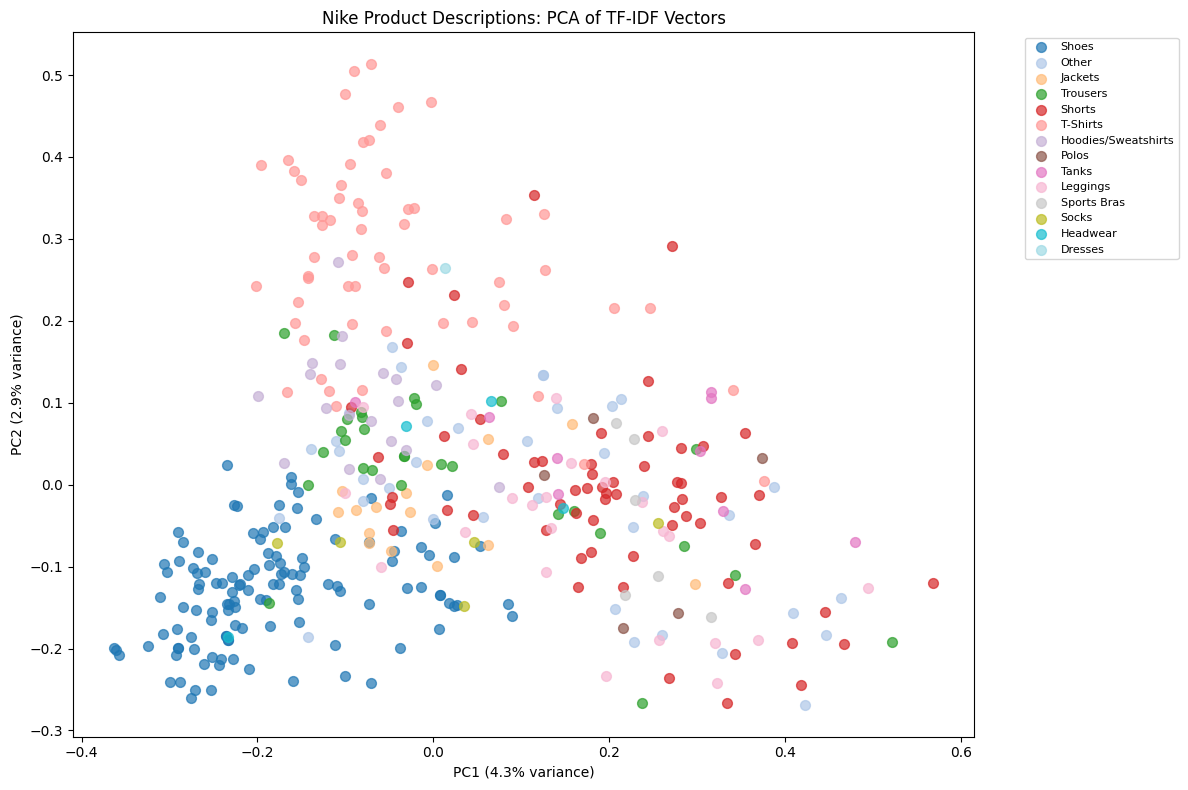

In [29]:
# Extract product descriptions
descriptions = nike_df['Product Description'].tolist()

# Create TF-IDF vectors
vectorizer = TfidfVectorizer(max_features=200, stop_words='english')
tfidf_matrix = vectorizer.fit_transform(descriptions)

print(f"TF-IDF matrix shape: {tfidf_matrix.shape}")
print(f"Original dimensions: {tfidf_matrix.shape[1]}")

# Apply PCA
pca = PCA(n_components=2, random_state=42)
pca_result = pca.fit_transform(tfidf_matrix.toarray())

print(f"\nPCA explained variance ratio:")
print(f"  PC1: {pca.explained_variance_ratio_[0]:.4f}")
print(f"  PC2: {pca.explained_variance_ratio_[1]:.4f}")
print(f"  Total: {sum(pca.explained_variance_ratio_):.4f}")

# Extract a simplified category from Subtitle (too many unique Subtitles otherwise)
def extract_category(subtitle):
    s = str(subtitle).lower()
    if 'shoe' in s:
        return 'Shoes'
    elif 'sock' in s:
        return 'Socks'
    elif 'short' in s:
        return 'Shorts'
    elif 't-shirt' in s or 'tee' in s:
        return 'T-Shirts'
    elif 'legging' in s:
        return 'Leggings'
    elif 'hoodie' in s or 'sweatshirt' in s:
        return 'Hoodies/Sweatshirts'
    elif 'jacket' in s:
        return 'Jackets'
    elif 'trouser' in s or 'pant' in s or 'jogger' in s:
        return 'Trousers'
    elif 'tank' in s:
        return 'Tanks'
    elif 'polo' in s:
        return 'Polos'
    elif 'bra' in s:
        return 'Sports Bras'
    elif 'dress' in s:
        return 'Dresses'
    elif 'hat' in s or 'beanie' in s:
        return 'Headwear'
    else:
        return 'Other'

# Create DataFrame with PCA results
pca_df = pd.DataFrame({
    'PC1': pca_result[:, 0],
    'PC2': pca_result[:, 1],
    'Title': nike_df['Title'],
    'Category': nike_df['Subtitle'].apply(extract_category)
})

# Create scatter plot
plt.figure(figsize=(12, 8))
categories = pca_df['Category'].unique()
colors = plt.cm.tab20(np.linspace(0, 1, len(categories)))

for cat, color in zip(categories, colors):
    subset = pca_df[pca_df['Category'] == cat]
    plt.scatter(subset['PC1'], subset['PC2'], label=cat, color=color, alpha=0.7, s=50)

plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% variance)')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% variance)')
plt.title('Nike Product Descriptions: PCA of TF-IDF Vectors')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=8)
plt.tight_layout()
plt.show()

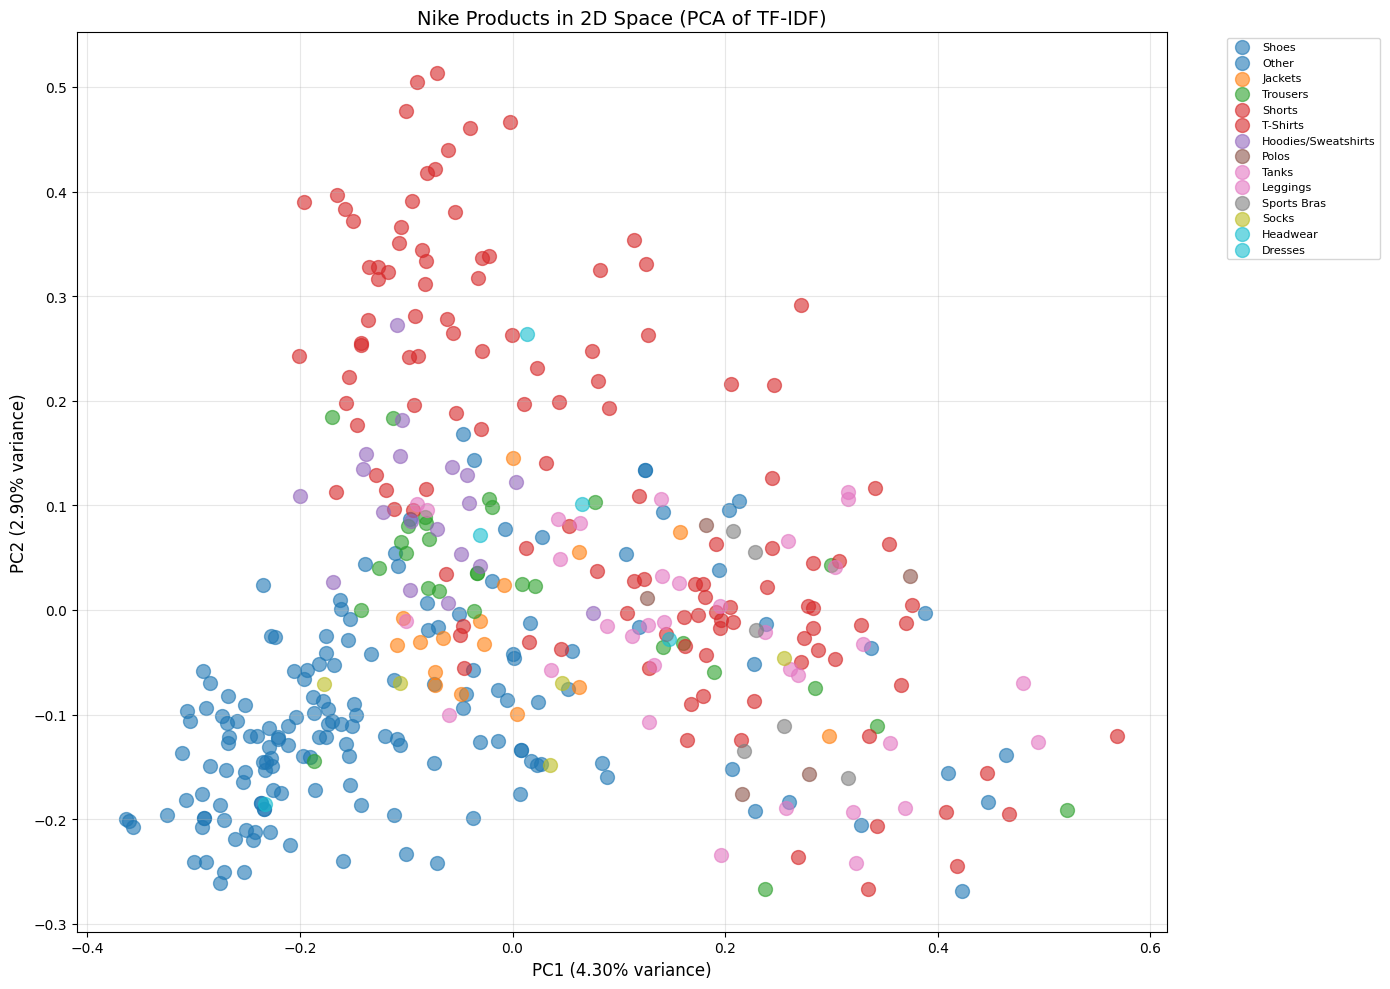

In [30]:
# Create visualization
plt.figure(figsize=(14, 10))

# Get unique categories for coloring
categories = pca_df['Category'].unique()
colors = plt.cm.tab10(np.linspace(0, 1, len(categories)))

# Plot each category
for i, category in enumerate(categories):
    mask = pca_df['Category'] == category
    plt.scatter(
        pca_df.loc[mask, 'PC1'],
        pca_df.loc[mask, 'PC2'],
        c=[colors[i]],
        label=category,
        alpha=0.6,
        s=100
    )

plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.2%} variance)', fontsize=12)
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.2%} variance)', fontsize=12)
plt.title('Nike Products in 2D Space (PCA of TF-IDF)', fontsize=14)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=8)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('nike_products_pca.png', dpi=150, bbox_inches='tight')
plt.show()

### Exercise E.2: Find Products in Similar Regions

Identify products that are close to each other in the PCA space.

In [31]:
def find_neighbors_in_pca_space(product_index, pca_df, n_neighbors=5):
    """
    Find products close to a given product in PCA space.

    Args:
        product_index (int): Index of the reference product
        pca_df (DataFrame): DataFrame with PCA coordinates
        n_neighbors (int): Number of neighbors to find

    Returns:
        DataFrame: Neighboring products with distances
    """
    ref_point = pca_df.iloc[product_index][['PC1', 'PC2']].values

    # Calculate distances
    distances = []
    for idx, row in pca_df.iterrows():
        if idx != product_index:
            point = row[['PC1', 'PC2']].values
            dist = np.linalg.norm(ref_point - point)
            distances.append((idx, dist))

    # Sort by distance
    distances.sort(key=lambda x: x[1])

    # Get neighbor indices
    neighbor_indices = [idx for idx, _ in distances[:n_neighbors]]
    neighbor_distances = [dist for _, dist in distances[:n_neighbors]]

    # Create results DataFrame
    results = pca_df.iloc[neighbor_indices].copy()
    results['Distance'] = neighbor_distances

    return results[['Title', 'Category', 'Distance']]

# Test with a few products
test_indices = [0, 10, 20]

for idx in test_indices:
    print(f"\nReference Product: {pca_df.iloc[idx]['Title']}")
    print(f"Category: {pca_df.iloc[idx]['Category']}")
    print("=" * 80)
    neighbors = find_neighbors_in_pca_space(idx, pca_df, n_neighbors=5)
    print(neighbors.to_string(index=False))
    print()


Reference Product: Nike Air Force 1 '07
Category: Shoes
                     Title Category  Distance
          Air Jordan 1 Mid    Shoes  0.016955
    Nike Dunk High Premium    Shoes  0.017868
Air Jordan 1 Retro High OG    Shoes  0.023455
       Nike Blazer Low '77    Shoes  0.023748
         Nike Waffle Debut    Shoes  0.030048


Reference Product: Air Jordan XXXVII Low PF
Category: Shoes
                           Title Category  Distance
NikeCourt Zoom Vapor Cage 4 Rafa    Shoes  0.006793
            Jordan Why Not .6 PF    Shoes  0.011231
Nike Air Force 1 '07 Next Nature    Shoes  0.041960
                       Nike BRSB    Shoes  0.044332
             Nike React Revision    Shoes  0.044663


Reference Product: Nike E-Series 1.0
Category: Shoes
                      Title Category  Distance
       Nike Air Force 1 '07    Shoes  0.001375
        Air Jordan 1 Mid SE    Shoes  0.011811
Nike Air Force 1 Mid '07 LX    Shoes  0.012091
    Nike Blazer Mid '77 ESS    Shoes  0.013015
   

### Exercise E.3: Analyze Documents from Both Datasets

Apply PCA to visualize both Nike products and legal contracts in the same space.

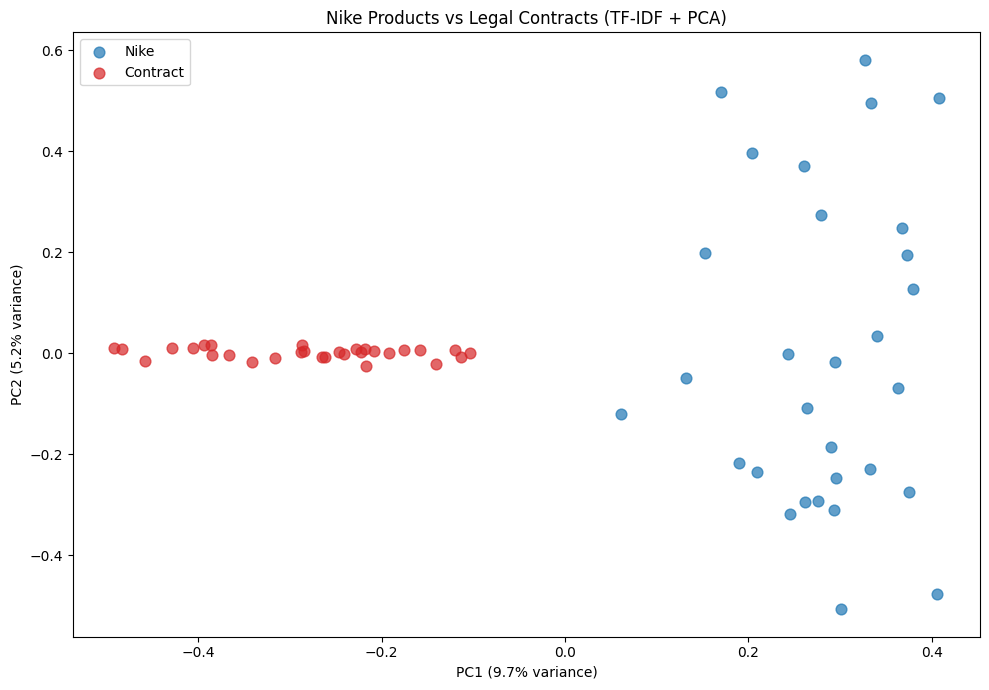

In [32]:
# 1. Combine Nike descriptions and contract texts (sample 30 from each)
# 2. Create TF-IDF vectors for combined corpus
# 3. Apply PCA to reduce to 2D
# 4. Create visualization with different colors for each dataset

# Sample documents
nike_sample = nike_df.sample(n=30, random_state=42)
contracts_sample = contracts_df.sample(n=30, random_state=42)

# Combine texts
nike_texts = nike_sample['Product Description'].tolist()
contract_texts = [text[:1000] for text in contracts_sample['text'].tolist()]  # Truncate for efficiency

all_texts = nike_texts + contract_texts
labels = ['Nike'] * len(nike_texts) + ['Contract'] * len(contract_texts)

# Create TF-IDF
vectorizer = TfidfVectorizer(max_features=200, stop_words='english')
tfidf_matrix = vectorizer.fit_transform(all_texts)

# Apply PCA
pca = PCA(n_components=2, random_state=42)
pca_result = pca.fit_transform(tfidf_matrix.toarray())

# Create DataFrame with PCA results
combined_pca_df = pd.DataFrame({
    'PC1': pca_result[:, 0],
    'PC2': pca_result[:, 1],
    'Source': labels
})

# Visualize -> use different colors for 'Nike' and 'Contract'
plt.figure(figsize=(10, 7))
for source, color in zip(['Nike', 'Contract'], ['#1f77b4', '#d62728']):
    subset = combined_pca_df[combined_pca_df['Source'] == source]
    plt.scatter(subset['PC1'], subset['PC2'], label=source, color=color, alpha=0.7, s=60)

plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% variance)')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% variance)')
plt.title('Nike Products vs Legal Contracts (TF-IDF + PCA)')
plt.legend()
plt.tight_layout()
plt.show()

### Written Question E.1 (Personal Interpretation)

Analyze the PCA visualizations:

1. **Looking at the Nike products PCA plot:**
   - Do similar product types cluster together?
   - Can you identify any patterns or groups?
   - What might the two principal components represent?

2. **Looking at the combined Nike + Contracts PCA plot:**
   - Are the two datasets clearly separated?
   - What does this separation (or lack thereof) tell you?
   - Are there any Nike products close to legal contracts? Why might this be?

3. **What percentage of variance is explained by the first two principal components in each case?**
   - Is this high or low?
   - What does this mean for the quality of the 2D representation?

**YOUR ANSWER:**

1. Nike products PCA analysis:
   - Clustering: Shoes tend to cluster together. Apparel items (T-shirts, shorts) form a separate, looser cluster.
   - Patterns: Categories overlap somewhat, since marketing language is shared across product types. Some categories (Socks, Headwear) are too small to form clear clusters.
   - PC interpretation: PC1 likely separates footwear vocabulary from apparel vocabulary.PC2 likely captures finer style or material differences (e.g. "leather", "knit", "mesh").

2. Combined datasets PCA analysis:
   - Separation:Nike and Contract points form two distinct, well-separated groups.
   - Interpretation: This shows the two text types use almost entirely different vocabularies.
   - Proximity cases: A few Nike points may sit closer to contracts if they contain formal terms (e.g. "agreement", policy text in product care instructions).
   These are rare exceptions, not the norm.

3. Variance explained:
   - Nike products: about 7% total (PC1 ≈ 4.3%, PC2 ≈ 2.9%). This is low.
   - Combined:
   - Quality interpretation: Low variance means 2D only shows a small part of the full structure.
   TF-IDF creates high-dimensional, sparse data, so PCA loses a lot of information in 2D.
   The plot is still useful for visualization, but distances should be read cautiously.

---

## Part F: Bonus Challenge - Dependency Parsing


### Bonus Exercise: Visualize Sentence Structure

Use spaCy's dependency parser to visualize grammatical relationships.

In [33]:
from spacy import displacy

# 1. Choose an interesting sentence from Nike or contracts
# 2. Parse it with spaCy
# 3. Visualize the dependency tree
# 4. Identify the root verb, subjects, and objects

sample_sentence = "The Nike Air Force 1 '07 crosses hardwood comfort with off-court flair."

doc = nlp(sample_sentence)

# Display dependency visualization
displacy.render(doc, style="dep", jupyter=True, options={"distance": 100})

# Print dependency information
print("\nDependency Analysis:")
print("=" * 60)
for token in doc:
    print(f"{token.text:15} | HEAD: {token.head.text:15} | DEP: {token.dep_:10} | POS: {token.pos_}")

# Identify the root verb, subjects, and objects
print("\nKey elements:")
print("=" * 60)
for token in doc:
    if token.dep_ == "ROOT":
        print(f"Root verb: {token.text}")
    elif token.dep_ in ("nsubj", "nsubjpass"):
        print(f"Subject: {token.text}")
    elif token.dep_ in ("dobj", "pobj", "attr"):
        print(f"Object: {token.text}")


Dependency Analysis:
The             | HEAD: Force           | DEP: det        | POS: DET
Nike            | HEAD: Force           | DEP: compound   | POS: PROPN
Air             | HEAD: Force           | DEP: compound   | POS: PROPN
Force           | HEAD: hardwood        | DEP: nsubj      | POS: PROPN
1               | HEAD: Force           | DEP: nummod     | POS: NUM
'               | HEAD: Force           | DEP: punct      | POS: NUM
07              | HEAD: crosses         | DEP: nummod     | POS: NUM
crosses         | HEAD: Force           | DEP: appos      | POS: NOUN
hardwood        | HEAD: hardwood        | DEP: ROOT       | POS: VERB
comfort         | HEAD: hardwood        | DEP: dobj       | POS: NOUN
with            | HEAD: hardwood        | DEP: prep       | POS: ADP
off             | HEAD: court           | DEP: compound   | POS: ADP
-               | HEAD: court           | DEP: punct      | POS: PUNCT
court           | HEAD: flair           | DEP: compound   | POS: NOUN


---

## Summary

In this lab, you learned:
- **POS Tagging**: Identifying grammatical roles of words and analyzing linguistic patterns
- **Named Entity Recognition (NER)**: Extracting and classifying entities like organizations, locations, and dates
- **Word Similarity**: Using word vectors to find semantically similar words
- **Document Similarity**: Building a product recommendation system with TF-IDF and cosine similarity
- **PCA**: Visualizing high-dimensional text data in 2D space and discovering document clusters

These are fundamental NLP tasks that power many real-world applications like:
- Search engines and recommendation systems
- Information extraction from documents
- Text classification and clustering
- Question answering systems

---

## Submission Checklist

Before submitting, ensure you have:

- [ ] Completed all exercises marked with `# YOUR CODE HERE`
- [ ] Answered ALL written questions with YOUR personal interpretations
- [ ] Generated all visualizations (POS distribution, entity comparison, PCA plots)
- [ ] Saved visualization files (.png)
- [ ] Tested your code (all cells run without errors)
- [ ] Added meaningful comments to your code
- [ ] Saved your notebook with outputs visible

**Final Steps:**
1. Save this notebook
2. Push to your Git repository
3. Send the repository link to: **yoroba93@gmail.com**

